In [2]:
# ============================================================
# EXPERIMENT 7
# Dimensionality Reduction and Model Evaluation
# With and Without PCA
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.base import clone

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# ============================================================
# LOAD DATASET
# ============================================================

# Column names for WDBC dataset

columns = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

# Read dataset
df = pd.read_csv("wdbc.data", header=None, names=columns)

# Convert target labels
df["Diagnosis"] = df["Diagnosis"].map({"M": 1, "B": 0})

# Features and Target
X = df.drop(["ID", "Diagnosis"], axis=1)
y = df["Diagnosis"]

print("="*70)
print("DATASET INFORMATION")
print("="*70)

print("Dataset : Breast Cancer Wisconsin Diagnostic (WDBC)")
print("Source  : UCI Machine Learning Repository")
print("Samples :", X.shape[0])
print("Features:", X.shape[1])

print("\nTarget Classes")
print("0 = Benign")
print("1 = Malignant")

print("\nClass Distribution")
print(y.value_counts())

print("\nClass Distribution (%)")
print((y.value_counts(normalize=True)*100).round(2))

print("\nMissing Values :", X.isnull().sum().sum())

print("\nFirst Five Rows")
display(df.head())

DATASET INFORMATION
Dataset : Breast Cancer Wisconsin Diagnostic (WDBC)
Source  : UCI Machine Learning Repository
Samples : 569
Features: 30

Target Classes
0 = Benign
1 = Malignant

Class Distribution
Diagnosis
0    357
1    212
Name: count, dtype: int64

Class Distribution (%)
Diagnosis
0    62.74
1    37.26
Name: proportion, dtype: float64

Missing Values : 0

First Five Rows


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# ============================================================
# TRAIN - TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 70)
print("TRAIN - TEST SPLIT")
print("=" * 70)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Training features: {X_train.shape[1]}")
print(f"Testing features : {X_test.shape[1]}")

print("\nTraining class distribution")
print(y_train.value_counts())

print("\nTesting class distribution")
print(y_test.value_counts())

TRAIN - TEST SPLIT
Training samples : 455
Testing samples  : 114
Training features: 30
Testing features : 30

Training class distribution
Diagnosis
0    285
1    170
Name: count, dtype: int64

Testing class distribution
Diagnosis
0    72
1    42
Name: count, dtype: int64


In [5]:
# ============================================================
# CELLSTANDARDIZATION
# ============================================================

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("=" * 70)
print("STANDARDIZATION")
print("=" * 70)

print("Standardization method : StandardScaler")
print("Original number of features:", X_train.shape[1])
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape :", X_test_scaled.shape)

print("\nStandardization completed successfully!")

STANDARDIZATION
Standardization method : StandardScaler
Original number of features: 30
Training data shape: (455, 30)
Testing data shape : (114, 30)

Standardization completed successfully!


In [6]:
# ============================================================
# PCA ANALYSIS
# ============================================================

print("=" * 70)
print("PCA ANALYSIS")
print("=" * 70)

# Apply PCA with all components first
pca_full = PCA()

X_train_pca_full = pca_full.fit_transform(X_train_scaled)

# Explained variance ratio
explained_variance = pca_full.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Find number of components required to retain 95% variance
n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print("Original number of features :", X_train.shape[1])

print(
    "Components required for 95% variance :",
    n_components_95
)

print(
    "Variance explained by selected components :",
    round(cumulative_variance[n_components_95 - 1] * 100, 2),
    "%"
)

# ============================================================
# CREATE PCA WITH SELECTED COMPONENTS
# ============================================================

pca = PCA(
    n_components=n_components_95
)

# Fit PCA only on training data
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform test data
X_test_pca = pca.transform(X_test_scaled)

print("\nPCA TRANSFORMATION")
print("-" * 70)

print(
    "Original feature shape :",
    X_train_scaled.shape
)

print(
    "Reduced feature shape  :",
    X_train_pca.shape
)

print(
    "Total variance retained:",
    round(
        np.sum(pca.explained_variance_ratio_) * 100,
        2
    ),
    "%"
)

PCA ANALYSIS
Original number of features : 30
Components required for 95% variance : 10
Variance explained by selected components : 95.21 %

PCA TRANSFORMATION
----------------------------------------------------------------------
Original feature shape : (455, 30)
Reduced feature shape  : (455, 10)
Total variance retained: 95.21 %


TABLE 1 : PCA VARIANCE EXPLAINED


,Component,Individual Variance (%),Cumulative Variance (%)
0,1,44.5935,44.5935
1,2,18.5453,63.1388
2,3,9.5846,72.7234
3,4,6.5938,79.3172
4,5,5.6223,84.9395
5,6,3.9885,88.9280
6,7,2.2145,91.1425
7,8,1.6140,92.7565
8,9,1.2848,94.0412
9,10,1.1657,95.2069


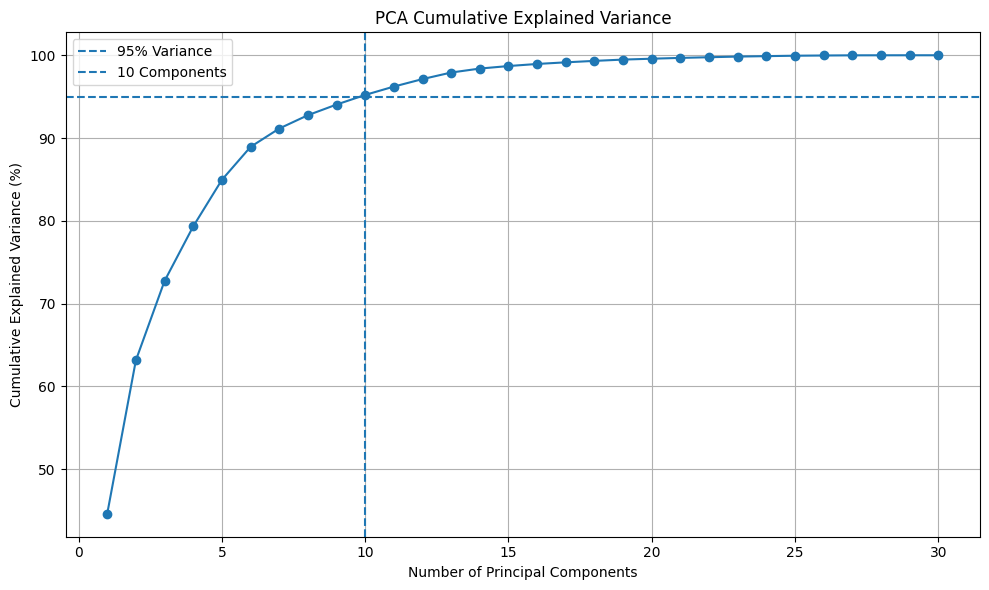


PCA DESIGN CHOICE
----------------------------------------------------------------------
Variance target selected : 95%
Original features        : 30
Selected components      : 10
Variance retained        : 95.21%

Justification:
PCA was used to reduce dimensionality while retaining at least 95% of the information present in the original feature space.


In [7]:
# ============================================================
# PCA VARIANCE PLOT + TABLE 1
# ============================================================

print("=" * 70)
print("TABLE 1 : PCA VARIANCE EXPLAINED")
print("=" * 70)

# Create PCA summary table for all components
pca_summary = pd.DataFrame({
    "Component": range(1, len(explained_variance) + 1),
    "Individual Variance (%)": explained_variance * 100,
    "Cumulative Variance (%)": cumulative_variance * 100
})

# Display the table
display(
    pca_summary.round(4)
)

# Save Table 1
pca_summary.to_csv(
    "Table1_PCA_Variance.csv",
    index=False
)

# ============================================================
# PCA CUMULATIVE EXPLAINED VARIANCE PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker="o"
)

plt.axhline(
    y=95,
    linestyle="--",
    label="95% Variance"
)

plt.axvline(
    x=n_components_95,
    linestyle="--",
    label=f"{n_components_95} Components"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")

plt.title(
    "PCA Cumulative Explained Variance"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "pca_variance_plot.png",
    dpi=300
)

plt.show()

# ============================================================
# PCA DESIGN CHOICE
# ============================================================

print("\nPCA DESIGN CHOICE")
print("-" * 70)

print(
    f"Variance target selected : 95%"
)

print(
    f"Original features        : {X.shape[1]}"
)

print(
    f"Selected components      : {n_components_95}"
)

print(
    f"Variance retained        : "
    f"{cumulative_variance[n_components_95 - 1] * 100:.2f}%"
)

print(
    "\nJustification:"
)

print(
    "PCA was used to reduce dimensionality while retaining "
    "at least 95% of the information present in the original "
    "feature space."
)

In [8]:
# ============================================================
# DEFINE MACHINE LEARNING MODELS
# ============================================================

print("=" * 70)
print("MODEL DEFINITIONS")
print("=" * 70)

models = {

    # 1. Support Vector Machine
    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    # 2. Naive Bayes
    "Naive Bayes": GaussianNB(),

    # 3. K-Nearest Neighbors
    "KNN": KNeighborsClassifier(),

    # 4. Logistic Regression
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    # 5. Decision Tree
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    # 6. Random Forest
    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    # 7. AdaBoost
    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    # 8. Gradient Boosting
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    # 9. XGBoost
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

# Display model names

print("\nModels included in the experiment:\n")

for i, model_name in enumerate(models.keys(), start=1):
    print(f"{i}. {model_name}")

print("\nTotal individual models:", len(models))

MODEL DEFINITIONS

Models included in the experiment:

1. SVM
2. Naive Bayes
3. KNN
4. Logistic Regression
5. Decision Tree
6. Random Forest
7. AdaBoost
8. Gradient Boosting
9. XGBoost

Total individual models: 9


In [9]:
# ============================================================
# HYPERPARAMETER GRIDS
# ============================================================

print("=" * 70)
print("HYPERPARAMETER SEARCH GRIDS")
print("=" * 70)

param_grids = {

    # ========================================================
    # 1. SUPPORT VECTOR MACHINE
    # ========================================================
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },

    # ========================================================
    # 2. NAIVE BAYES
    # ========================================================
    "Naive Bayes": {
        "var_smoothing": [
            1e-11,
            1e-10,
            1e-9,
            1e-8
        ]
    },

    # ========================================================
    # 3. K-NEAREST NEIGHBORS
    # ========================================================
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    },

    # ========================================================
    # 4. LOGISTIC REGRESSION
    # ========================================================
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"]
    },

    # ========================================================
    # 5. DECISION TREE
    # ========================================================
    "Decision Tree": {
        "max_depth": [None, 3, 5, 10],
        "min_samples_split": [2, 5, 10],
        "criterion": ["gini", "entropy"]
    },

    # ========================================================
    # 6. RANDOM FOREST
    # ========================================================
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5]
    },

    # ========================================================
    # 7. ADABOOST
    # ========================================================
    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1.0]
    },

    # ========================================================
    # 8. GRADIENT BOOSTING
    # ========================================================
    "Gradient Boosting": {
        "n_estimators": [50, 100],
        "learning_rate": [0.01, 0.1],
        "max_depth": [2, 3]
    },

    # ========================================================
    # 9. XGBOOST
    # ========================================================
    "XGBoost": {
        "n_estimators": [50, 100],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1]
    }
}

# ============================================================
# DISPLAY HYPERPARAMETER GRIDS
# ============================================================

for model_name, grid in param_grids.items():

    print("\n" + "-" * 70)
    print(model_name)
    print("-" * 70)

    for parameter, values in grid.items():
        print(f"{parameter}: {values}")

print("\nHyperparameter grids defined successfully!")

HYPERPARAMETER SEARCH GRIDS

----------------------------------------------------------------------
SVM
----------------------------------------------------------------------
C: [0.1, 1, 10]
kernel: ['linear', 'rbf']
gamma: ['scale', 'auto']

----------------------------------------------------------------------
Naive Bayes
----------------------------------------------------------------------
var_smoothing: [1e-11, 1e-10, 1e-09, 1e-08]

----------------------------------------------------------------------
KNN
----------------------------------------------------------------------
n_neighbors: [3, 5, 7, 9]
weights: ['uniform', 'distance']
metric: ['euclidean', 'manhattan']

----------------------------------------------------------------------
Logistic Regression
----------------------------------------------------------------------
C: [0.01, 0.1, 1, 10]
solver: ['liblinear', 'lbfgs']

----------------------------------------------------------------------
Decision Tree
----------------

In [10]:
# ============================================================
# 5-FOLD CROSS-VALIDATION + HYPERPARAMETER TUNING
# ============================================================

print("=" * 70)
print("CROSS-VALIDATION SETUP")
print("=" * 70)

# ============================================================
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Metrics to record
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

print("Cross-validation method : Stratified K-Fold")
print("Number of folds         : 5")
print("Shuffle                 : True")
print("Random state            : 42")

# ============================================================
# HYPERPARAMETER TUNING FUNCTION
# ============================================================

def tune_model(
    model,
    param_grid,
    X_data,
    y_data,
    model_name,
    setting
):
    
    print("\n" + "=" * 70)
    print(f"TUNING: {model_name} | {setting}")
    print("=" * 70)

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring="f1",
        n_jobs=-1,
        return_train_score=True
    )

    grid.fit(X_data, y_data)

    print("\nBest Parameters:")
    print(grid.best_params_)

    print(
        "\nBest CV F1 Score:",
        round(grid.best_score_, 4)
    )

    return grid


print("\nTuning function created successfully!")
print("GridSearchCV will select the best parameters using F1-score.")

CROSS-VALIDATION SETUP
Cross-validation method : Stratified K-Fold
Number of folds         : 5
Shuffle                 : True
Random state            : 42

Tuning function created successfully!
GridSearchCV will select the best parameters using F1-score.


In [11]:
# ============================================================
# HYPERPARAMETER TUNING
#             NO-PCA vs WITH-PCA
# ============================================================

print("=" * 70)
print("HYPERPARAMETER TUNING - ALL MODELS")
print("=" * 70)

# Store best models
best_models_no_pca = {}
best_models_pca = {}

# Store tuning results
tuning_results = []

# ============================================================
# TUNE EACH MODEL
# ============================================================

for model_name, model in models.items():

    print("\n")
    print("#" * 70)
    print(f"PROCESSING MODEL: {model_name}")
    print("#" * 70)

    # ========================================================
    # NO PCA
    # ========================================================

    grid_no_pca = tune_model(
        model=model,
        param_grid=param_grids[model_name],
        X_data=X_train_scaled,
        y_data=y_train,
        model_name=model_name,
        setting="No-PCA"
    )

    best_no_pca = grid_no_pca.best_estimator_

    best_models_no_pca[model_name] = best_no_pca

    tuning_results.append({
        "Model": model_name,
        "Setting": "No-PCA",
        "Best Parameters": str(grid_no_pca.best_params_),
        "Best CV F1": grid_no_pca.best_score_
    })

    # ========================================================
    # WITH PCA
    # ========================================================

    grid_pca = tune_model(
        model=model,
        param_grid=param_grids[model_name],
        X_data=X_train_pca,
        y_data=y_train,
        model_name=model_name,
        setting="With-PCA"
    )

    best_pca = grid_pca.best_estimator_

    best_models_pca[model_name] = best_pca

    tuning_results.append({
        "Model": model_name,
        "Setting": "With-PCA",
        "Best Parameters": str(grid_pca.best_params_),
        "Best CV F1": grid_pca.best_score_
    })


# ============================================================
# CREATE TUNING RESULTS TABLE
# ============================================================

tuning_df = pd.DataFrame(tuning_results)

print("\n")
print("=" * 70)
print("HYPERPARAMETER TUNING SUMMARY")
print("=" * 70)

display(
    tuning_df.round(4)
)

# Save complete tuning results
tuning_df.to_csv(
    "Hyperparameter_Tuning_Results.csv",
    index=False
)

print("\nTuning completed successfully!")
print("Results saved as: Hyperparameter_Tuning_Results.csv")

HYPERPARAMETER TUNING - ALL MODELS


######################################################################
PROCESSING MODEL: SVM
######################################################################

TUNING: SVM | No-PCA

Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Best CV F1 Score: 0.9674

TUNING: SVM | With-PCA

Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Best CV F1 Score: 0.9618


######################################################################
PROCESSING MODEL: Naive Bayes
######################################################################

TUNING: Naive Bayes | No-PCA

Best Parameters:
{'var_smoothing': 1e-11}

Best CV F1 Score: 0.917

TUNING: Naive Bayes | With-PCA

Best Parameters:
{'var_smoothing': 1e-11}

Best CV F1 Score: 0.8762


######################################################################
PROCESSING MODEL: KNN
######################################################################

TUNING: KNN | No-PCA

Best Paramete

,Model,Setting,Best Parameters,Best CV F1
0,SVM,No-PCA,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9674
1,SVM,With-PCA,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9618
2,Naive Bayes,No-PCA,{'var_smoothing': 1e-11},0.9170
3,Naive Bayes,With-PCA,{'var_smoothing': 1e-11},0.8762
4,KNN,No-PCA,"{'metric': 'manhattan', 'n_neighbors': 3, 'wei...",0.9667
5,KNN,With-PCA,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.9605
6,Logistic Regression,No-PCA,"{'C': 1, 'solver': 'liblinear'}",0.9640
7,Logistic Regression,With-PCA,"{'C': 0.1, 'solver': 'liblinear'}",0.9701
8,Decision Tree,No-PCA,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.9039
9,Decision Tree,With-PCA,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.9329



Tuning completed successfully!
Results saved as: Hyperparameter_Tuning_Results.csv


In [12]:
# ============================================================
# CELL 11 : 5-FOLD CROSS-VALIDATION RESULTS
#             NO-PCA vs WITH-PCA
# ============================================================

print("=" * 70)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

# Store fold-wise results
fold_results = []

# ============================================================
# EVALUATE EACH MODEL
# ============================================================

for model_name in models.keys():

    print("\n" + "-" * 70)
    print(f"Evaluating: {model_name}")
    print("-" * 70)

    # --------------------------------------------------------
    # NO PCA
    # --------------------------------------------------------

    best_no_pca = best_models_no_pca[model_name]

    cv_no_pca = cross_validate(
        best_no_pca,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    # --------------------------------------------------------
    # WITH PCA
    # --------------------------------------------------------

    best_pca = best_models_pca[model_name]

    cv_pca = cross_validate(
        best_pca,
        X_train_pca,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    # --------------------------------------------------------
    # STORE EACH FOLD
    # --------------------------------------------------------

    for fold in range(5):

        fold_results.append({

            "Model": model_name,

            "Fold": fold + 1,

            "Accuracy_No_PCA":
                cv_no_pca["test_accuracy"][fold],

            "Precision_No_PCA":
                cv_no_pca["test_precision"][fold],

            "Recall_No_PCA":
                cv_no_pca["test_recall"][fold],

            "F1_No_PCA":
                cv_no_pca["test_f1"][fold],

            "Accuracy_With_PCA":
                cv_pca["test_accuracy"][fold],

            "Precision_With_PCA":
                cv_pca["test_precision"][fold],

            "Recall_With_PCA":
                cv_pca["test_recall"][fold],

            "F1_With_PCA":
                cv_pca["test_f1"][fold]
        })

    # --------------------------------------------------------
    # PRINT AVERAGES FOR CURRENT MODEL
    # --------------------------------------------------------

    print(
        "No-PCA Average Accuracy:",
        round(cv_no_pca["test_accuracy"].mean(), 4)
    )

    print(
        "With-PCA Average Accuracy:",
        round(cv_pca["test_accuracy"].mean(), 4)
    )

    print(
        "No-PCA Average F1:",
        round(cv_no_pca["test_f1"].mean(), 4)
    )

    print(
        "With-PCA Average F1:",
        round(cv_pca["test_f1"].mean(), 4)
    )


# ============================================================
# CREATE FOLD-WISE DATAFRAME
# ============================================================

results_df = pd.DataFrame(fold_results)

print("\n")
print("=" * 70)
print("FOLD-WISE RESULTS")
print("=" * 70)

display(
    results_df.round(4)
)

# ============================================================
# SAVE RESULTS
# ============================================================

results_df.to_csv(
    "Table5_Fold_Wise_Results.csv",
    index=False
)

print("\nFold-wise results saved as:")
print("Table5_Fold_Wise_Results.csv")

5-FOLD CROSS-VALIDATION RESULTS

----------------------------------------------------------------------
Evaluating: SVM
----------------------------------------------------------------------
No-PCA Average Accuracy: 0.9758
With-PCA Average Accuracy: 0.9714
No-PCA Average F1: 0.9674
With-PCA Average F1: 0.9618

----------------------------------------------------------------------
Evaluating: Naive Bayes
----------------------------------------------------------------------
No-PCA Average Accuracy: 0.9385
With-PCA Average Accuracy: 0.9121
No-PCA Average F1: 0.917
With-PCA Average F1: 0.8762

----------------------------------------------------------------------
Evaluating: KNN
----------------------------------------------------------------------
No-PCA Average Accuracy: 0.9758
With-PCA Average Accuracy: 0.9714
No-PCA Average F1: 0.9667
With-PCA Average F1: 0.9605

----------------------------------------------------------------------
Evaluating: Logistic Regression
--------------------

,Model,Fold,Accuracy_No_PCA,Precision_No_PCA,Recall_No_PCA,F1_No_PCA,Accuracy_With_PCA,Precision_With_PCA,Recall_With_PCA,F1_With_PCA
0,SVM,1,0.9670,1.0000,0.9118,0.9538,0.9560,0.9688,0.9118,0.9394
1,SVM,2,0.9890,0.9714,1.0000,0.9855,0.9890,0.9714,1.0000,0.9855
2,SVM,3,0.9670,0.9429,0.9706,0.9565,0.9560,0.9167,0.9706,0.9429
3,SVM,4,0.9780,0.9706,0.9706,0.9706,0.9780,0.9706,0.9706,0.9706
4,SVM,5,0.9780,0.9706,0.9706,0.9706,0.9780,0.9706,0.9706,0.9706
5,Naive Bayes,1,0.9560,1.0000,0.8824,0.9375,0.9121,0.9643,0.7941,0.8710
6,Naive Bayes,2,0.9780,0.9444,1.0000,0.9714,0.9670,0.9697,0.9412,0.9552
7,Naive Bayes,3,0.9121,0.8611,0.9118,0.8857,0.8901,0.8529,0.8529,0.8529
8,Naive Bayes,4,0.9121,0.9062,0.8529,0.8788,0.8791,0.9259,0.7353,0.8197
9,Naive Bayes,5,0.9341,0.9118,0.9118,0.9118,0.9121,0.8824,0.8824,0.8824



Fold-wise results saved as:
Table5_Fold_Wise_Results.csv


In [13]:
# ============================================================
#TABLE 5 - 5-FOLD CROSS-VALIDATION
#             NO-PCA vs WITH-PCA
# ============================================================

print("=" * 70)
print("TABLE 5 : 5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

table5_results = []

for model_name in models.keys():

    model_data = results_df[
        results_df["Model"] == model_name
    ].sort_values("Fold")

    # --------------------------------------------------------
    # ACCURACY RESULTS
    # --------------------------------------------------------

    accuracy_no_pca = model_data[
        "Accuracy_No_PCA"
    ].values

    accuracy_pca = model_data[
        "Accuracy_With_PCA"
    ].values

    table5_results.append({
        "Model": model_name,

        "Fold 1 (No PCA)": accuracy_no_pca[0],
        "Fold 2 (No PCA)": accuracy_no_pca[1],
        "Fold 3 (No PCA)": accuracy_no_pca[2],
        "Fold 4 (No PCA)": accuracy_no_pca[3],
        "Fold 5 (No PCA)": accuracy_no_pca[4],

        "Avg (No PCA)": accuracy_no_pca.mean(),

        "Fold 1 (With PCA)": accuracy_pca[0],
        "Fold 2 (With PCA)": accuracy_pca[1],
        "Fold 3 (With PCA)": accuracy_pca[2],
        "Fold 4 (With PCA)": accuracy_pca[3],
        "Fold 5 (With PCA)": accuracy_pca[4],

        "Avg (With PCA)": accuracy_pca.mean()
    })


table5_df = pd.DataFrame(table5_results)

# ============================================================
# DISPLAY TABLE
# ============================================================

display(
    table5_df.round(4)
)

# ============================================================
# SAVE TABLE 5
# ============================================================

table5_df.to_csv(
    "Table5_Cross_Validation_Accuracy.csv",
    index=False
)

print("\nTable 5 saved as:")
print("Table5_Cross_Validation_Accuracy.csv")


# ============================================================
# F1 SCORE TABLE
# ============================================================

print("\n")
print("=" * 70)
print("F1-SCORE CROSS-VALIDATION RESULTS")
print("=" * 70)

f1_table_results = []

for model_name in models.keys():

    model_data = results_df[
        results_df["Model"] == model_name
    ].sort_values("Fold")

    f1_no_pca = model_data[
        "F1_No_PCA"
    ].values

    f1_pca = model_data[
        "F1_With_PCA"
    ].values

    f1_table_results.append({

        "Model": model_name,

        "Fold 1 (No PCA)": f1_no_pca[0],
        "Fold 2 (No PCA)": f1_no_pca[1],
        "Fold 3 (No PCA)": f1_no_pca[2],
        "Fold 4 (No PCA)": f1_no_pca[3],
        "Fold 5 (No PCA)": f1_no_pca[4],

        "Avg (No PCA)": f1_no_pca.mean(),

        "Fold 1 (With PCA)": f1_pca[0],
        "Fold 2 (With PCA)": f1_pca[1],
        "Fold 3 (With PCA)": f1_pca[2],
        "Fold 4 (With PCA)": f1_pca[3],
        "Fold 5 (With PCA)": f1_pca[4],

        "Avg (With PCA)": f1_pca.mean()
    })


f1_table_df = pd.DataFrame(
    f1_table_results
)

display(
    f1_table_df.round(4)
)

f1_table_df.to_csv(
    "F1_Cross_Validation_Results.csv",
    index=False
)

print("\nF1-score table saved as:")
print("F1_Cross_Validation_Results.csv")

TABLE 5 : 5-FOLD CROSS-VALIDATION RESULTS


,Model,Fold 1 (No PCA),Fold 2 (No PCA),Fold 3 (No PCA),Fold 4 (No PCA),Fold 5 (No PCA),Avg (No PCA),Fold 1 (With PCA),Fold 2 (With PCA),Fold 3 (With PCA),Fold 4 (With PCA),Fold 5 (With PCA),Avg (With PCA)
0,SVM,0.9670,0.9890,0.9670,0.9780,0.9780,0.9758,0.9560,0.989,0.9560,0.9780,0.9780,0.9714
1,Naive Bayes,0.9560,0.9780,0.9121,0.9121,0.9341,0.9385,0.9121,0.967,0.8901,0.8791,0.9121,0.9121
2,KNN,0.9670,1.0000,0.9670,0.9560,0.9890,0.9758,0.9780,0.978,0.9670,0.9451,0.9890,0.9714
3,Logistic Regression,0.9560,0.9670,1.0000,0.9780,0.9670,0.9736,0.9780,0.967,0.9780,0.9780,0.9890,0.9780
4,Decision Tree,0.9011,0.9451,0.9121,0.9341,0.9560,0.9297,0.9451,0.967,0.9451,0.9231,0.9670,0.9495
5,Random Forest,0.9670,1.0000,0.9451,0.9451,0.9780,0.9670,0.9670,0.978,0.9560,0.9451,0.9451,0.9582
6,AdaBoost,0.9780,0.9780,0.9451,0.9670,0.9890,0.9714,0.9560,0.978,0.9780,0.9560,0.9670,0.9670
7,Gradient Boosting,0.9670,0.9670,0.9451,0.9670,0.9890,0.9670,0.9451,0.967,0.9341,0.9560,0.9780,0.9560
8,XGBoost,0.9560,0.9780,0.9560,0.9670,0.9890,0.9692,0.9670,0.978,0.9670,0.9560,0.9560,0.9648



Table 5 saved as:
Table5_Cross_Validation_Accuracy.csv


F1-SCORE CROSS-VALIDATION RESULTS


,Model,Fold 1 (No PCA),Fold 2 (No PCA),Fold 3 (No PCA),Fold 4 (No PCA),Fold 5 (No PCA),Avg (No PCA),Fold 1 (With PCA),Fold 2 (With PCA),Fold 3 (With PCA),Fold 4 (With PCA),Fold 5 (With PCA),Avg (With PCA)
0,SVM,0.9538,0.9855,0.9565,0.9706,0.9706,0.9674,0.9394,0.9855,0.9429,0.9706,0.9706,0.9618
1,Naive Bayes,0.9375,0.9714,0.8857,0.8788,0.9118,0.9170,0.8710,0.9552,0.8529,0.8197,0.8824,0.8762
2,KNN,0.9552,1.0000,0.9538,0.9394,0.9851,0.9667,0.9697,0.9706,0.9538,0.9231,0.9851,0.9605
3,Logistic Regression,0.9375,0.9565,1.0000,0.9697,0.9565,0.9640,0.9697,0.9565,0.9697,0.9697,0.9851,0.9701
4,Decision Tree,0.8657,0.9275,0.8750,0.9118,0.9394,0.9039,0.9254,0.9577,0.9275,0.8986,0.9552,0.9329
5,Random Forest,0.9552,1.0000,0.9231,0.9275,0.9706,0.9553,0.9538,0.9714,0.9412,0.9231,0.9254,0.9430
6,AdaBoost,0.9697,0.9706,0.9231,0.9565,0.9851,0.9610,0.9375,0.9706,0.9706,0.9394,0.9552,0.9547
7,Gradient Boosting,0.9552,0.9565,0.9231,0.9565,0.9851,0.9553,0.9206,0.9577,0.9118,0.9394,0.9697,0.9398
8,XGBoost,0.9412,0.9714,0.9394,0.9565,0.9851,0.9587,0.9538,0.9714,0.9552,0.9394,0.9394,0.9519



F1-score table saved as:
F1_Cross_Validation_Results.csv


In [14]:
# ============================================================
#AVERAGE MODEL PERFORMANCE
# ============================================================

print("=" * 70)
print("AVERAGE MODEL PERFORMANCE")
print("=" * 70)

average_results = []

for model_name in models.keys():

    model_data = results_df[
        results_df["Model"] == model_name
    ]

    average_results.append({

        "Model": model_name,

        # ----------------------------------------------------
        # NO PCA
        # ----------------------------------------------------

        "Accuracy_No_PCA":
            model_data["Accuracy_No_PCA"].mean(),

        "Precision_No_PCA":
            model_data["Precision_No_PCA"].mean(),

        "Recall_No_PCA":
            model_data["Recall_No_PCA"].mean(),

        "F1_No_PCA":
            model_data["F1_No_PCA"].mean(),

        # ----------------------------------------------------
        # WITH PCA
        # ----------------------------------------------------

        "Accuracy_With_PCA":
            model_data["Accuracy_With_PCA"].mean(),

        "Precision_With_PCA":
            model_data["Precision_With_PCA"].mean(),

        "Recall_With_PCA":
            model_data["Recall_With_PCA"].mean(),

        "F1_With_PCA":
            model_data["F1_With_PCA"].mean()
    })


average_df = pd.DataFrame(
    average_results
)

# ============================================================
# CALCULATE IMPROVEMENT AFTER PCA
# ============================================================

average_df["Accuracy_Change"] = (
    average_df["Accuracy_With_PCA"]
    -
    average_df["Accuracy_No_PCA"]
)

average_df["Precision_Change"] = (
    average_df["Precision_With_PCA"]
    -
    average_df["Precision_No_PCA"]
)

average_df["Recall_Change"] = (
    average_df["Recall_With_PCA"]
    -
    average_df["Recall_No_PCA"]
)

average_df["F1_Change"] = (
    average_df["F1_With_PCA"]
    -
    average_df["F1_No_PCA"]
)

# ============================================================
# DISPLAY RESULTS
# ============================================================

display(
    average_df.round(4)
)

# ============================================================
# SAVE RESULTS
# ============================================================

average_df.to_csv(
    "Model_Average_Comparison.csv",
    index=False
)

print("\nAverage performance table saved as:")
print("Model_Average_Comparison.csv")

AVERAGE MODEL PERFORMANCE


,Model,Accuracy_No_PCA,Precision_No_PCA,Recall_No_PCA,F1_No_PCA,Accuracy_With_PCA,Precision_With_PCA,Recall_With_PCA,F1_With_PCA,Accuracy_Change,Precision_Change,Recall_Change,F1_Change
0,SVM,0.9758,0.9711,0.9647,0.9674,0.9714,0.9596,0.9647,0.9618,-0.0044,-0.0115,0.0000,-0.0056
1,Naive Bayes,0.9385,0.9247,0.9118,0.9170,0.9121,0.9190,0.8412,0.8762,-0.0264,-0.0057,-0.0706,-0.0408
2,KNN,0.9758,0.9877,0.9471,0.9667,0.9714,0.9877,0.9353,0.9605,-0.0044,-0.0000,-0.0118,-0.0063
3,Logistic Regression,0.9736,0.9771,0.9529,0.9640,0.9780,0.9886,0.9529,0.9701,0.0044,0.0114,0.0000,0.0061
4,Decision Tree,0.9297,0.9214,0.8882,0.9039,0.9495,0.9256,0.9412,0.9329,0.0198,0.0042,0.0529,0.0290
5,Random Forest,0.9670,0.9645,0.9471,0.9553,0.9582,0.9586,0.9294,0.9430,-0.0088,-0.0059,-0.0176,-0.0123
6,AdaBoost,0.9714,0.9762,0.9471,0.9610,0.9670,0.9759,0.9353,0.9547,-0.0044,-0.0003,-0.0118,-0.0063
7,Gradient Boosting,0.9670,0.9646,0.9471,0.9553,0.9560,0.9599,0.9235,0.9398,-0.0110,-0.0047,-0.0235,-0.0154
8,XGBoost,0.9692,0.9594,0.9588,0.9587,0.9648,0.9703,0.9353,0.9519,-0.0044,0.0109,-0.0235,-0.0069



Average performance table saved as:
Model_Average_Comparison.csv


In [ ]:
# ============================================================
#TEST SET EVALUATION
# ============================================================

print("=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)

# Store test results
test_results = []

# ============================================================
# TRAIN BEST MODELS
# ============================================================

for model_name in models.keys():

    print(f"\nTraining {model_name}...")

    # --------------------------------------------------------
    # NO PCA
    # --------------------------------------------------------

    model_no_pca = best_models_no_pca[model_name]

    model_no_pca.fit(
        X_train_scaled,
        y_train
    )

    y_pred_no_pca = model_no_pca.predict(
        X_test_scaled
    )

    # --------------------------------------------------------
    # WITH PCA
    # --------------------------------------------------------

    model_pca = best_models_pca[model_name]

    model_pca.fit(
        X_train_pca,
        y_train
    )

    y_pred_pca = model_pca.predict(
        X_test_pca
    )

    # --------------------------------------------------------
    # CALCULATE METRICS
    # --------------------------------------------------------

    test_results.append({

        "Model": model_name,

        # No PCA
        "Accuracy_No_PCA":
            accuracy_score(
                y_test,
                y_pred_no_pca
            ),

        "Precision_No_PCA":
            precision_score(
                y_test,
                y_pred_no_pca
            ),

        "Recall_No_PCA":
            recall_score(
                y_test,
                y_pred_no_pca
            ),

        "F1_No_PCA":
            f1_score(
                y_test,
                y_pred_no_pca
            ),

        # With PCA
        "Accuracy_With_PCA":
            accuracy_score(
                y_test,
                y_pred_pca
            ),

        "Precision_With_PCA":
            precision_score(
                y_test,
                y_pred_pca
            ),

        "Recall_With_PCA":
            recall_score(
                y_test,
                y_pred_pca
            ),

        "F1_With_PCA":
            f1_score(
                y_test,
                y_pred_pca
            )
    })


# ============================================================
# CREATE DATAFRAME
# ============================================================

test_results_df = pd.DataFrame(
    test_results
)

print("\n")
print("=" * 70)
print("TEST SET PERFORMANCE")
print("=" * 70)

display(
    test_results_df.round(4)
)

# ============================================================
# SAVE RESULTS
# ============================================================

test_results_df.to_csv(
    "Test_Set_Results.csv",
    index=False
)

print("\nTest results saved as:")
print("Test_Set_Results.csv")

TEST SET EVALUATION

Training SVM...

Training Naive Bayes...

Training KNN...

Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training AdaBoost...

Training Gradient Boosting...

Training XGBoost...


In [ ]:
# ============================================================
# CONFUSION MATRICES
# ============================================================

print("=" * 70)
print("CONFUSION MATRICES")
print("=" * 70)

# Models selected for confusion matrix analysis
selected_models = [
    "SVM",
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

# Class labels
class_names = [
    "Benign",
    "Malignant"
]

# ============================================================
# GENERATE CONFUSION MATRICES
# ============================================================

for model_name in selected_models:

    print("\n" + "-" * 70)
    print(model_name)
    print("-" * 70)

    # ========================================================
    # NO PCA
    # ========================================================

    model_no_pca = best_models_no_pca[model_name]

    y_pred_no_pca = model_no_pca.predict(
        X_test_scaled
    )

    cm_no_pca = confusion_matrix(
        y_test,
        y_pred_no_pca
    )

    print("\nConfusion Matrix - No PCA")
    print(cm_no_pca)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm_no_pca,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.title(
        f"{model_name} - Confusion Matrix - No PCA"
    )

    plt.tight_layout()

    filename_no_pca = (
        model_name.replace(" ", "_")
        + "_Confusion_No_PCA.png"
    )

    plt.savefig(
        filename_no_pca,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ========================================================
    # WITH PCA
    # ========================================================

    model_pca = best_models_pca[model_name]

    y_pred_pca = model_pca.predict(
        X_test_pca
    )

    cm_pca = confusion_matrix(
        y_test,
        y_pred_pca
    )

    print("\nConfusion Matrix - With PCA")
    print(cm_pca)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm_pca,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.title(
        f"{model_name} - Confusion Matrix - With PCA"
    )

    plt.tight_layout()

    filename_pca = (
        model_name.replace(" ", "_")
        + "_Confusion_With_PCA.png"
    )

    plt.savefig(
        filename_pca,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

print("\nAll confusion matrices generated successfully!")

In [ ]:
# ============================================================
# ROC CURVES
# ============================================================

print("=" * 70)
print("ROC CURVES - PCA vs NO PCA")
print("=" * 70)

plt.figure(figsize=(11, 8))

# ============================================================
# GENERATE ROC CURVES
# ============================================================

for model_name in selected_models:

    # ========================================================
    # NO PCA
    # ========================================================

    model_no_pca = best_models_no_pca[model_name]

    # Get probability/decision scores
    if hasattr(model_no_pca, "predict_proba"):
        y_score_no_pca = model_no_pca.predict_proba(
            X_test_scaled
        )[:, 1]
    else:
        y_score_no_pca = model_no_pca.decision_function(
            X_test_scaled
        )

    # Calculate ROC
    fpr_no_pca, tpr_no_pca, _ = roc_curve(
        y_test,
        y_score_no_pca
    )

    roc_auc_no_pca = auc(
        fpr_no_pca,
        tpr_no_pca
    )

    # Plot No-PCA
    plt.plot(
        fpr_no_pca,
        tpr_no_pca,
        label=f"{model_name} No-PCA "
              f"(AUC = {roc_auc_no_pca:.3f})"
    )

    # ========================================================
    # WITH PCA
    # ========================================================

    model_pca = best_models_pca[model_name]

    if hasattr(model_pca, "predict_proba"):
        y_score_pca = model_pca.predict_proba(
            X_test_pca
        )[:, 1]
    else:
        y_score_pca = model_pca.decision_function(
            X_test_pca
        )

    # Calculate ROC
    fpr_pca, tpr_pca, _ = roc_curve(
        y_test,
        y_score_pca
    )

    roc_auc_pca = auc(
        fpr_pca,
        tpr_pca
    )

    # Plot PCA
    plt.plot(
        fpr_pca,
        tpr_pca,
        linestyle="--",
        label=f"{model_name} PCA "
              f"(AUC = {roc_auc_pca:.3f})"
    )

# ============================================================
# RANDOM CLASSIFIER LINE
# ============================================================

plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    label="Random Classifier"
)

# ============================================================
# LABELS AND TITLE
# ============================================================

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves - PCA vs No PCA"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)

plt.tight_layout()

# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    "ROC_Curves_PCA_vs_No_PCA.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nROC curve generated successfully!")
print("Saved as: ROC_Curves_PCA_vs_No_PCA.png")

In [ ]:
# ============================================================
# PRECISION-RECALL CURVES
#             PCA vs NO PCA
# ============================================================

print("=" * 70)
print("PRECISION-RECALL CURVES - PCA vs NO PCA")
print("=" * 70)

plt.figure(figsize=(11, 8))

# ============================================================
# GENERATE PRECISION-RECALL CURVES
# ============================================================

for model_name in selected_models:

    # ========================================================
    # NO PCA
    # ========================================================

    model_no_pca = best_models_no_pca[model_name]

    # Get prediction scores
    if hasattr(model_no_pca, "predict_proba"):
        y_score_no_pca = model_no_pca.predict_proba(
            X_test_scaled
        )[:, 1]
    else:
        y_score_no_pca = model_no_pca.decision_function(
            X_test_scaled
        )

    # Calculate Precision-Recall values
    precision_no_pca, recall_no_pca, _ = precision_recall_curve(
        y_test,
        y_score_no_pca
    )

    # Average Precision
    ap_no_pca = average_precision_score(
        y_test,
        y_score_no_pca
    )

    # Plot No-PCA
    plt.plot(
        recall_no_pca,
        precision_no_pca,
        label=f"{model_name} No-PCA "
              f"(AP = {ap_no_pca:.3f})"
    )

    # ========================================================
    # WITH PCA
    # ========================================================

    model_pca = best_models_pca[model_name]

    if hasattr(model_pca, "predict_proba"):
        y_score_pca = model_pca.predict_proba(
            X_test_pca
        )[:, 1]
    else:
        y_score_pca = model_pca.decision_function(
            X_test_pca
        )

    # Calculate Precision-Recall values
    precision_pca, recall_pca, _ = precision_recall_curve(
        y_test,
        y_score_pca
    )

    # Average Precision
    ap_pca = average_precision_score(
        y_test,
        y_score_pca
    )

    # Plot PCA
    plt.plot(
        recall_pca,
        precision_pca,
        linestyle="--",
        label=f"{model_name} PCA "
              f"(AP = {ap_pca:.3f})"
    )

# ============================================================
# GRAPH LABELS
# ============================================================

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curves - PCA vs No PCA"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)

plt.tight_layout()

# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    "Precision_Recall_Curves_PCA_vs_No_PCA.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nPrecision-Recall curves generated successfully!")
print(
    "Saved as: Precision_Recall_Curves_PCA_vs_No_PCA.png"
)

In [ ]:
# ============================================================
# CELL 18 : STACKING CLASSIFIER
#             NO PCA vs WITH PCA
# ============================================================

print("=" * 70)
print("STACKING CLASSIFIER")
print("=" * 70)

# ============================================================
# BASE LEARNERS
# ============================================================

base_learners = [

    (
        "lr",
        LogisticRegression(
            C=1,
            max_iter=5000,
            random_state=42
        )
    ),

    (
        "svm",
        SVC(
            C=1,
            kernel="rbf",
            probability=True,
            random_state=42
        )
    ),

    (
        "knn",
        KNeighborsClassifier(
            n_neighbors=5
        )
    )
]

# ============================================================
# META LEARNER
# ============================================================

meta_learner = LogisticRegression(
    max_iter=5000,
    random_state=42
)

# ============================================================
# CREATE STACKING MODEL
# ============================================================

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1
)

print("\nBase Learners:")
print("1. Logistic Regression")
print("2. SVM")
print("3. KNN")

print("\nMeta Learner:")
print("Logistic Regression")

# ============================================================
# STACKING - NO PCA
# ============================================================

print("\n" + "-" * 70)
print("STACKING - NO PCA")
print("-" * 70)

stacking_no_pca = clone(stacking_model)

stacking_no_pca.fit(
    X_train_scaled,
    y_train
)

stack_pred_no_pca = stacking_no_pca.predict(
    X_test_scaled
)

stack_accuracy_no_pca = accuracy_score(
    y_test,
    stack_pred_no_pca
)

stack_precision_no_pca = precision_score(
    y_test,
    stack_pred_no_pca
)

stack_recall_no_pca = recall_score(
    y_test,
    stack_pred_no_pca
)

stack_f1_no_pca = f1_score(
    y_test,
    stack_pred_no_pca
)

print(
    "Accuracy :", round(stack_accuracy_no_pca, 4)
)

print(
    "Precision:", round(stack_precision_no_pca, 4)
)

print(
    "Recall   :", round(stack_recall_no_pca, 4)
)

print(
    "F1 Score :", round(stack_f1_no_pca, 4)
)

# ============================================================
# STACKING - WITH PCA
# ============================================================

print("\n" + "-" * 70)
print("STACKING - WITH PCA")
print("-" * 70)

stacking_pca = clone(stacking_model)

stacking_pca.fit(
    X_train_pca,
    y_train
)

stack_pred_pca = stacking_pca.predict(
    X_test_pca
)

stack_accuracy_pca = accuracy_score(
    y_test,
    stack_pred_pca
)

stack_precision_pca = precision_score(
    y_test,
    stack_pred_pca
)

stack_recall_pca = recall_score(
    y_test,
    stack_pred_pca
)

stack_f1_pca = f1_score(
    y_test,
    stack_pred_pca
)

print(
    "Accuracy :", round(stack_accuracy_pca, 4)
)

print(
    "Precision:", round(stack_precision_pca, 4)
)

print(
    "Recall   :", round(stack_recall_pca, 4)
)

print(
    "F1 Score :", round(stack_f1_pca, 4)
)

# ============================================================
# STACKING RESULTS TABLE
# ============================================================

stacking_results = pd.DataFrame([

    {
        "Model": "Stacking",
        "Setting": "No-PCA",
        "Accuracy": stack_accuracy_no_pca,
        "Precision": stack_precision_no_pca,
        "Recall": stack_recall_no_pca,
        "F1": stack_f1_no_pca
    },

    {
        "Model": "Stacking",
        "Setting": "With-PCA",
        "Accuracy": stack_accuracy_pca,
        "Precision": stack_precision_pca,
        "Recall": stack_recall_pca,
        "F1": stack_f1_pca
    }

])

print("\n")
print("=" * 70)
print("STACKING TEST SET RESULTS")
print("=" * 70)

display(
    stacking_results.round(4)
)

# ============================================================
# SAVE STACKING RESULTS
# ============================================================

stacking_results.to_csv(
    "Stacking_Test_Results.csv",
    index=False
)

print(
    "\nSaved as: Stacking_Test_Results.csv"
)

In [ ]:
# ============================================================
# STACKING - 5-FOLD CROSS-VALIDATION
#             NO PCA vs WITH PCA
# ============================================================

print("=" * 70)
print("STACKING - 5-FOLD CROSS-VALIDATION")
print("=" * 70)

# ============================================================
# STACKING - NO PCA
# ============================================================

print("\nRunning 5-Fold CV for Stacking - No PCA...")

stack_cv_no_pca = cross_validate(
    stacking_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# ============================================================
# STACKING - WITH PCA
# ============================================================

print("Running 5-Fold CV for Stacking - With PCA...")

stack_cv_pca = cross_validate(
    stacking_model,
    X_train_pca,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# ============================================================
# DISPLAY FOLD-WISE RESULTS
# ============================================================

print("\n")
print("-" * 70)
print("STACKING FOLD-WISE RESULTS")
print("-" * 70)

stacking_cv_results = []

for fold in range(5):

    stacking_cv_results.append({

        "Model": "Stacking",

        "Fold": fold + 1,

        "Accuracy_No_PCA":
            stack_cv_no_pca[
                "test_accuracy"
            ][fold],

        "Precision_No_PCA":
            stack_cv_no_pca[
                "test_precision"
            ][fold],

        "Recall_No_PCA":
            stack_cv_no_pca[
                "test_recall"
            ][fold],

        "F1_No_PCA":
            stack_cv_no_pca[
                "test_f1"
            ][fold],

        "Accuracy_With_PCA":
            stack_cv_pca[
                "test_accuracy"
            ][fold],

        "Precision_With_PCA":
            stack_cv_pca[
                "test_precision"
            ][fold],

        "Recall_With_PCA":
            stack_cv_pca[
                "test_recall"
            ][fold],

        "F1_With_PCA":
            stack_cv_pca[
                "test_f1"
            ][fold]
    })


stacking_cv_df = pd.DataFrame(
    stacking_cv_results
)

display(
    stacking_cv_df.round(4)
)

# ============================================================
# ADD STACKING TO MAIN RESULTS
# ============================================================

results_df = pd.concat(
    [
        results_df,
        stacking_cv_df
    ],
    ignore_index=True
)

# ============================================================
# SAVE UPDATED RESULTS
# ============================================================

results_df.to_csv(
    "All_Models_5Fold_CV_Results.csv",
    index=False
)

print("\nUpdated results saved as:")
print("All_Models_5Fold_CV_Results.csv")

# ============================================================
# STACKING AVERAGE
# ============================================================

print("\n")
print("-" * 70)
print("STACKING AVERAGE CV PERFORMANCE")
print("-" * 70)

print(
    "No-PCA Accuracy:",
    round(
        stack_cv_no_pca["test_accuracy"].mean(),
        4
    )
)

print(
    "With-PCA Accuracy:",
    round(
        stack_cv_pca["test_accuracy"].mean(),
        4
    )
)

print(
    "No-PCA F1:",
    round(
        stack_cv_no_pca["test_f1"].mean(),
        4
    )
)

print(
    "With-PCA F1:",
    round(
        stack_cv_pca["test_f1"].mean(),
        4
    )
)

In [ ]:
# ============================================================
# FINAL 10-MODEL PCA COMPARISON
# ============================================================

print("=" * 70)
print("FINAL PCA COMPARISON - ALL 10 MODELS")
print("=" * 70)

final_results = []

# ============================================================
# CALCULATE AVERAGE CV PERFORMANCE
# ============================================================

for model_name in results_df["Model"].unique():

    model_data = results_df[
        results_df["Model"] == model_name
    ]

    # --------------------------------------------------------
    # NO PCA AVERAGES
    # --------------------------------------------------------

    accuracy_no_pca = model_data[
        "Accuracy_No_PCA"
    ].mean()

    precision_no_pca = model_data[
        "Precision_No_PCA"
    ].mean()

    recall_no_pca = model_data[
        "Recall_No_PCA"
    ].mean()

    f1_no_pca = model_data[
        "F1_No_PCA"
    ].mean()

    # --------------------------------------------------------
    # WITH PCA AVERAGES
    # --------------------------------------------------------

    accuracy_pca = model_data[
        "Accuracy_With_PCA"
    ].mean()

    precision_pca = model_data[
        "Precision_With_PCA"
    ].mean()

    recall_pca = model_data[
        "Recall_With_PCA"
    ].mean()

    f1_pca = model_data[
        "F1_With_PCA"
    ].mean()

    # --------------------------------------------------------
    # ADD RESULTS
    # --------------------------------------------------------

    final_results.append({

        "Model": model_name,

        "Accuracy_No_PCA":
            accuracy_no_pca,

        "Accuracy_With_PCA":
            accuracy_pca,

        "Accuracy_Change":
            accuracy_pca - accuracy_no_pca,

        "Precision_No_PCA":
            precision_no_pca,

        "Precision_With_PCA":
            precision_pca,

        "Precision_Change":
            precision_pca - precision_no_pca,

        "Recall_No_PCA":
            recall_no_pca,

        "Recall_With_PCA":
            recall_pca,

        "Recall_Change":
            recall_pca - recall_no_pca,

        "F1_No_PCA":
            f1_no_pca,

        "F1_With_PCA":
            f1_pca,

        "F1_Change":
            f1_pca - f1_no_pca
    })


final_comparison_df = pd.DataFrame(
    final_results
)

# ============================================================
# DISPLAY FINAL TABLE
# ============================================================

display(
    final_comparison_df.round(4)
)

# ============================================================
# SAVE FINAL TABLE
# ============================================================

final_comparison_df.to_csv(
    "FINAL_10_MODEL_PCA_COMPARISON.csv",
    index=False
)

print("\nFinal comparison saved as:")
print("FINAL_10_MODEL_PCA_COMPARISON.csv")

In [ ]:
# ============================================================
# ACCURACY COMPARISON
#             ALL 10 MODELS - NO PCA vs WITH PCA
# ============================================================

print("=" * 70)
print("ACCURACY COMPARISON - ALL 10 MODELS")
print("=" * 70)

# Copy final comparison dataframe
plot_df = final_comparison_df.copy()

# Model positions
x = np.arange(len(plot_df["Model"]))

# Bar width
width = 0.35

# ============================================================
# CREATE BAR GRAPH
# ============================================================

plt.figure(figsize=(14, 7))

plt.bar(
    x - width / 2,
    plot_df["Accuracy_No_PCA"],
    width,
    label="No PCA"
)

plt.bar(
    x + width / 2,
    plot_df["Accuracy_With_PCA"],
    width,
    label="With PCA"
)

# ============================================================
# LABELS
# ============================================================

plt.xticks(
    x,
    plot_df["Model"],
    rotation=45,
    ha="right"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.title(
    "Accuracy Comparison: No PCA vs With PCA"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

# ============================================================
# SAVE GRAPH
# ============================================================

plt.savefig(
    "Accuracy_Comparison_All_10_Models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nAccuracy comparison graph generated successfully!")
print(
    "Saved as: Accuracy_Comparison_All_10_Models.png"
)

In [ ]:
# ============================================================
# F1-SCORE COMPARISON
#             ALL 10 MODELS - NO PCA vs WITH PCA
# ============================================================

print("=" * 70)
print("F1-SCORE COMPARISON - ALL 10 MODELS")
print("=" * 70)

# Copy final comparison dataframe
plot_df = final_comparison_df.copy()

# Model positions
x = np.arange(len(plot_df["Model"]))

# Bar width
width = 0.35

# ============================================================
# CREATE BAR GRAPH
# ============================================================

plt.figure(figsize=(14, 7))

plt.bar(
    x - width / 2,
    plot_df["F1_No_PCA"],
    width,
    label="No PCA"
)

plt.bar(
    x + width / 2,
    plot_df["F1_With_PCA"],
    width,
    label="With PCA"
)

# ============================================================
# LABELS
# ============================================================

plt.xticks(
    x,
    plot_df["Model"],
    rotation=45,
    ha="right"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("F1 Score")

plt.title(
    "F1 Score Comparison: No PCA vs With PCA"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

# ============================================================
# SAVE GRAPH
# ============================================================

plt.savefig(
    "F1_Score_Comparison_All_10_Models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nF1-score comparison graph generated successfully!")
print(
    "Saved as: F1_Score_Comparison_All_10_Models.png"
)

In [ ]:
# ============================================================
# STABILITY ANALYSIS
#             NO PCA vs WITH PCA
# ============================================================

print("=" * 70)
print("STABILITY ANALYSIS")
print("=" * 70)

stability_results = []

# ============================================================
# CALCULATE STANDARD DEVIATION ACROSS 5 FOLDS
# ============================================================

for model_name in results_df["Model"].unique():

    model_data = results_df[
        results_df["Model"] == model_name
    ]

    # Accuracy standard deviation
    std_no_pca = model_data[
        "Accuracy_No_PCA"
    ].std()

    std_with_pca = model_data[
        "Accuracy_With_PCA"
    ].std()

    # Determine whether stability improved
    if std_with_pca < std_no_pca:
        stability = "Improved"
    elif std_with_pca > std_no_pca:
        stability = "Reduced"
    else:
        stability = "Same"

    stability_results.append({

        "Model": model_name,

        "Std Accuracy - No PCA":
            std_no_pca,

        "Std Accuracy - With PCA":
            std_with_pca,

        "Change in Std":
            std_with_pca - std_no_pca,

        "Stability After PCA":
            stability
    })


# ============================================================
# CREATE DATAFRAME
# ============================================================

stability_df = pd.DataFrame(
    stability_results
)

# ============================================================
# DISPLAY RESULTS
# ============================================================

display(
    stability_df.round(4)
)

# ============================================================
# SAVE RESULTS
# ============================================================

stability_df.to_csv(
    "Stability_Analysis.csv",
    index=False
)

print("\nStability analysis saved as:")
print("Stability_Analysis.csv")

# ============================================================
# COUNT IMPROVED / REDUCED / SAME
# ============================================================

improved_count = (
    stability_df["Stability After PCA"] == "Improved"
).sum()

reduced_count = (
    stability_df["Stability After PCA"] == "Reduced"
).sum()

same_count = (
    stability_df["Stability After PCA"] == "Same"
).sum()

print("\n")
print("-" * 70)
print("STABILITY SUMMARY")
print("-" * 70)

print(
    "Models with improved stability:",
    improved_count
)

print(
    "Models with reduced stability:",
    reduced_count
)

print(
    "Models with same stability:",
    same_count
)

In [ ]:
# ============================================================
# AUTOMATIC OBSERVATIONS
# ============================================================

print("=" * 70)
print("AUTOMATIC OBSERVATIONS")
print("=" * 70)

# ============================================================
# 1. MODEL WITH MAXIMUM ACCURACY IMPROVEMENT
# ============================================================

best_accuracy = final_comparison_df.loc[
    final_comparison_df["Accuracy_Change"].idxmax()
]

print("\n1. MODEL WITH MAXIMUM ACCURACY IMPROVEMENT")
print("-" * 70)

print(
    "Model:",
    best_accuracy["Model"]
)

print(
    "Accuracy Change:",
    round(
        best_accuracy["Accuracy_Change"],
        4
    )
)

print(
    "No-PCA Accuracy:",
    round(
        best_accuracy["Accuracy_No_PCA"],
        4
    )
)

print(
    "With-PCA Accuracy:",
    round(
        best_accuracy["Accuracy_With_PCA"],
        4
    )
)


# ============================================================
# 2. MODEL WITH MAXIMUM F1 IMPROVEMENT
# ============================================================

best_f1 = final_comparison_df.loc[
    final_comparison_df["F1_Change"].idxmax()
]

print("\n2. MODEL WITH MAXIMUM F1 IMPROVEMENT")
print("-" * 70)

print(
    "Model:",
    best_f1["Model"]
)

print(
    "F1 Change:",
    round(
        best_f1["F1_Change"],
        4
    )
)

print(
    "No-PCA F1:",
    round(
        best_f1["F1_No_PCA"],
        4
    )
)

print(
    "With-PCA F1:",
    round(
        best_f1["F1_With_PCA"],
        4
    )
)


# ============================================================
# 3. MODEL MOST NEGATIVELY AFFECTED BY PCA
# ============================================================

worst_f1 = final_comparison_df.loc[
    final_comparison_df["F1_Change"].idxmin()
]

print("\n3. MODEL MOST NEGATIVELY AFFECTED BY PCA")
print("-" * 70)

print(
    "Model:",
    worst_f1["Model"]
)

print(
    "F1 Change:",
    round(
        worst_f1["F1_Change"],
        4
    )
)


# ============================================================
# 4. NUMBER OF MODELS IMPROVED
# ============================================================

accuracy_improved = (
    final_comparison_df["Accuracy_Change"] > 0
).sum()

f1_improved = (
    final_comparison_df["F1_Change"] > 0
).sum()

print("\n4. MODELS IMPROVED AFTER PCA")
print("-" * 70)

print(
    "Accuracy improved:",
    accuracy_improved,
    "out of",
    len(final_comparison_df)
)

print(
    "F1-score improved:",
    f1_improved,
    "out of",
    len(final_comparison_df)
)


# ============================================================
# 5. BEST MODEL WITHOUT PCA
# ============================================================

best_no_pca = final_comparison_df.loc[
    final_comparison_df["Accuracy_No_PCA"].idxmax()
]

print("\n5. BEST MODEL WITHOUT PCA")
print("-" * 70)

print(
    "Model:",
    best_no_pca["Model"]
)

print(
    "Accuracy:",
    round(
        best_no_pca["Accuracy_No_PCA"],
        4
    )
)

print(
    "F1 Score:",
    round(
        best_no_pca["F1_No_PCA"],
        4
    )
)


# ============================================================
# 6. BEST MODEL WITH PCA
# ============================================================

best_with_pca = final_comparison_df.loc[
    final_comparison_df["Accuracy_With_PCA"].idxmax()
]

print("\n6. BEST MODEL WITH PCA")
print("-" * 70)

print(
    "Model:",
    best_with_pca["Model"]
)

print(
    "Accuracy:",
    round(
        best_with_pca["Accuracy_With_PCA"],
        4
    )
)

print(
    "F1 Score:",
    round(
        best_with_pca["F1_With_PCA"],
        4
    )
)


# ============================================================
# 7. STABILITY RESULTS
# ============================================================

stability_improved = (
    stability_df[
        "Stability After PCA"
    ] == "Improved"
).sum()

stability_reduced = (
    stability_df[
        "Stability After PCA"
    ] == "Reduced"
).sum()

print("\n7. STABILITY ANALYSIS")
print("-" * 70)

print(
    "Models with improved stability:",
    stability_improved
)

print(
    "Models with reduced stability:",
    stability_reduced
)


# ============================================================
# 8. LINEAR MODELS
# ============================================================

linear_models = [
    "SVM",
    "Logistic Regression"
]

linear_data = final_comparison_df[
    final_comparison_df["Model"].isin(
        linear_models
    )
]

print("\n8. LINEAR MODEL BEHAVIOUR")
print("-" * 70)

display(
    linear_data[
        [
            "Model",
            "Accuracy_No_PCA",
            "Accuracy_With_PCA",
            "Accuracy_Change",
            "F1_No_PCA",
            "F1_With_PCA",
            "F1_Change"
        ]
    ].round(4)
)


# ============================================================
# 9. ENSEMBLE MODELS
# ============================================================

ensemble_models = [
    "Random Forest",
    "AdaBoost",
    "Gradient Boosting",
    "XGBoost",
    "Stacking"
]

ensemble_data = final_comparison_df[
    final_comparison_df["Model"].isin(
        ensemble_models
    )
]

print("\n9. ENSEMBLE MODEL BEHAVIOUR")
print("-" * 70)

display(
    ensemble_data[
        [
            "Model",
            "Accuracy_No_PCA",
            "Accuracy_With_PCA",
            "Accuracy_Change",
            "F1_No_PCA",
            "F1_With_PCA",
            "F1_Change"
        ]
    ].round(4)
)


# ============================================================
# 10. AUTOMATIC CONCLUSION
# ============================================================

print("\n")
print("=" * 70)
print("AUTOMATIC OBSERVATION SUMMARY")
print("=" * 70)

if accuracy_improved > len(final_comparison_df) / 2:
    accuracy_statement = (
        "PCA improved accuracy for the majority of models."
    )
else:
    accuracy_statement = (
        "PCA did not improve accuracy for the majority of models."
    )

if f1_improved > len(final_comparison_df) / 2:
    f1_statement = (
        "PCA improved F1-score for the majority of models."
    )
else:
    f1_statement = (
        "PCA did not improve F1-score for the majority of models."
    )

if stability_improved > stability_reduced:
    stability_statement = (
        "PCA improved stability for more models than it reduced."
    )
else:
    stability_statement = (
        "PCA did not improve stability for the majority of models."
    )

print("\n" + accuracy_statement)

print(f1_statement)

print(stability_statement)

print(
    f"\nThe largest accuracy improvement was observed "
    f"for {best_accuracy['Model']}."
)

print(
    f"The largest F1-score improvement was observed "
    f"for {best_f1['Model']}."
)

print(
    f"The model with the largest F1-score decrease "
    f"after PCA was {worst_f1['Model']}."
)

print(
    f"\nBest accuracy without PCA: "
    f"{best_no_pca['Model']} "
    f"({best_no_pca['Accuracy_No_PCA']:.4f})"
)

print(
    f"Best accuracy with PCA: "
    f"{best_with_pca['Model']} "
    f"({best_with_pca['Accuracy_With_PCA']:.4f})"
)

In [ ]:
# ============================================================
# ORGANIZE ALL GENERATED FILES
# ============================================================

import os
import shutil

# ============================================================
# MAIN OUTPUT FOLDER
# ============================================================

main_folder = "/home/sangee/ml_lab/Experiment7_Output"

images_folder = os.path.join(main_folder, "Images")
csv_folder = os.path.join(main_folder, "CSV_Files")

os.makedirs(images_folder, exist_ok=True)
os.makedirs(csv_folder, exist_ok=True)


# ============================================================
# IMAGE FILES
# ============================================================

image_files = [
    "pca_variance_plot.png",

    "SVM_Confusion_No_PCA.png",
    "SVM_Confusion_With_PCA.png",

    "Logistic_Regression_Confusion_No_PCA.png",
    "Logistic_Regression_Confusion_With_PCA.png",

    "Random_Forest_Confusion_No_PCA.png",
    "Random_Forest_Confusion_With_PCA.png",

    "XGBoost_Confusion_No_PCA.png",
    "XGBoost_Confusion_With_PCA.png",

    "ROC_Curves_PCA_vs_No_PCA.png",
    "Precision_Recall_Curves_PCA_vs_No_PCA.png",

    "Accuracy_Comparison_All_10_Models.png",
    "F1_Score_Comparison_All_10_Models.png"
]


# ============================================================
# CSV FILES
# ============================================================

csv_files = [
    "Table1_PCA_Variance.csv",
    "Table5_Cross_Validation_Accuracy.csv",
    "Table5_Fold_Wise_Results.csv",

    "Model_Average_Comparison.csv",
    "Hyperparameter_Tuning_Results.csv",
    "Test_Set_Results.csv",

    "F1_Cross_Validation_Results.csv",
    "All_Models_5Fold_CV_Results.csv",

    "Stacking_Test_Results.csv",
    "FINAL_10_MODEL_PCA_COMPARISON.csv",

    "Stability_Analysis.csv"
]


# ============================================================
# COPY IMAGES
# ============================================================

print("=" * 70)
print("SAVING IMAGES")
print("=" * 70)

image_count = 0

for file in image_files:

    source = os.path.join("/home/sangee/ml_lab", file)
    destination = os.path.join(images_folder, file)

    if os.path.exists(source):

        shutil.copy2(source, destination)

        print("✓", file)

        image_count += 1

    else:

        print("⚠ Not found:", file)


# ============================================================
# COPY CSV FILES
# ============================================================

print("\n" + "=" * 70)
print("SAVING CSV FILES")
print("=" * 70)

csv_count = 0

for file in csv_files:

    source = os.path.join("/home/sangee/ml_lab", file)
    destination = os.path.join(csv_folder, file)

    if os.path.exists(source):

        shutil.copy2(source, destination)

        print("✓", file)

        csv_count += 1

    else:

        print("⚠ Not found:", file)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("EXPERIMENT 7 FILE ORGANIZATION COMPLETED")
print("=" * 70)

print("\nImages saved:", image_count)
print("CSV files saved:", csv_count)

print("\nMain folder:")
print(main_folder)

print("\nImages folder:")
print(images_folder)

print("\nCSV folder:")
print(csv_folder)